<a href="https://www.kaggle.com/code/lalit7881/global-weapons-arsenal-eda-100?scriptVersionId=315732367" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/maulikgajera/global-military-arsenal-dataset-weapons-systems/README.md
/kaggle/input/datasets/maulikgajera/global-military-arsenal-dataset-weapons-systems/Global Weapons Systems.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/maulikgajera/global-military-arsenal-dataset-weapons-systems/Global Weapons Systems.csv")

In [3]:
df.head()

,ID,Weapon_Name,Country_of_Origin,Manufacturer,Category,Subcategory,Year_Introduced,Year_Retired,Service_Status,Caliber,...,Generation,Theater_of_Operation,Export_Status,Combat_Proven,Propulsion_Type,Guidance_System,Communication_System,Operating_Environment,Protection_Level,Notes
0,1,M4A1 Carbine,USA,Colt/FN Herstal,Small Arm,Assault Rifle,1994,NaN,Active,5.56x45mm NATO,...,3rd,Land,Widely Exported,Yes,Gas-operated piston,Iron sights/Aimpoint/ACOG,Link 16 datalink,Urban,Composite + ERA,"Standard US military carbine; over 500,000 in ..."
1,2,M16A4,USA,FN Herstal,Small Arm,Assault Rifle,1985,NaN,Active,5.56x45mm NATO,...,3rd,Land,Exported,Yes,Gas-operated direct impingement,Iron sights/Optical scope,VHF radio,All-terrain,No armor,Service rifle of USMC; longer barrel for accuracy
2,3,XM5 SIG MCX Spear,USA,SIG Sauer,Small Arm,Assault Rifle,2022,NaN,Active,6.8x51mm,...,4th,Land,Limited Export,Yes,Gas-operated short stroke piston,Thermal + Image intensifier,Software Defined Radio,All-terrain,No armor,Next Gen Squad Weapon; new 6.8mm cartridge def...
3,4,M249 SAW,USA,FN Herstal,Small Arm,Light Machine Gun,1984,NaN,Active,5.56x45mm NATO,...,3rd,Land,Widely Exported,Yes,Gas-operated long stroke piston,Optical scope,VHF radio,All-terrain,No armor,Squad Automatic Weapon; 200-round soft pack
4,5,M240B,USA,FN Herstal,Small Arm,General Purpose Machine Gun,1977,NaN,Active,7.62x51mm NATO,...,3rd,Land,Exported,Yes,Gas-operated long stroke piston,Iron sights/Optical scope,VHF radio,All-terrain,No armor,Primary US GPMG; vehicle and dismounted roles


In [4]:
df.tail()

,ID,Weapon_Name,Country_of_Origin,Manufacturer,Category,Subcategory,Year_Introduced,Year_Retired,Service_Status,Caliber,...,Generation,Theater_of_Operation,Export_Status,Combat_Proven,Propulsion_Type,Guidance_System,Communication_System,Operating_Environment,Protection_Level,Notes
9995,9996,SA-442,Tunisia,State Defence Enterprise,Air Defense,Short-Range SAM,1949,NaN,Active,152mm,...,4.5th,Sea,Embargoed,Yes,NaN,Proximity radar fuse,UHF radio,Urban,Composite Chobham,4.5th generation Short-Range SAM; operated by ...
9996,9997,K-347,Syria,State Arsenal,Armored Vehicle,Reconnaissance Vehicle,1960,NaN,Reserve,25mm autocannon,...,6th (prototype),Land,Very Limited Export,Yes,Diesel V-8,Manual,SATCOM,Desert,No armor,6th (prototype) generation Reconnaissance Vehi...
9997,9998,RBS-389,Lebanon,Ministry Arms Factory,Air Defense,Medium-Range SAM,1974,NaN,Active,Various composite,...,5th+,Land,Exported,Yes,Manual,IR homing,IFF Mode 4/5,Jungle,Electro-optical APS,5th+ generation Medium-Range SAM; operated by ...
9998,9999,T-363,Chile,Ministry Arms Factory,Aircraft,Utility Helicopter,1974,NaN,Reserve,N/A (no gun),...,6th (prototype),Air,Exported,Limited,Rotary (turboshaft),Unguided,BLOS datalink,Underground,Composite Chobham,6th (prototype) generation Utility Helicopter;...
9999,10000,NSM-118,Finland,Government Defence Works,Missile,Ballistic SRBM,1999,NaN,Active,533mm,...,3.5th,Sea,Exported,Limited,Hypersonic scramjet,IR imaging,UHF radio,Littoral,Slat/Cage armor,3.5th generation Ballistic SRBM; operated by F...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 36 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     10000 non-null  int64  
 1   Weapon_Name            10000 non-null  object 
 2   Country_of_Origin      10000 non-null  object 
 3   Manufacturer           10000 non-null  object 
 4   Category               10000 non-null  object 
 5   Subcategory            10000 non-null  object 
 6   Year_Introduced        10000 non-null  int64  
 7   Year_Retired           740 non-null    float64
 8   Service_Status         10000 non-null  object 
 9   Caliber                9803 non-null   object 
 10  Action_Type            10000 non-null  object 
 11  Effective_Range_m      8614 non-null   float64
 12  Max_Range_m            8647 non-null   float64
 13  Weight_kg              9593 non-null   float64
 14  Length_mm              7473 non-null   float64
 15  Bar

In [6]:
df.describe()

,ID,Year_Introduced,Year_Retired,Effective_Range_m,Max_Range_m,Weight_kg,Length_mm,Barrel_Length_mm,Muzzle_Velocity_mps,Rate_of_Fire_rpm,Warhead_Weight_kg,Max_Speed_kmh,Crew_Size,Unit_Cost_USD,Num_Operator_Nations
count,10000.00000,10000.000000,740.000000,8.614000e+03,8.647000e+03,9.593000e+03,7473.000000,1628.000000,1648.000000,2411.000000,4551.000000,2437.000000,10000.000000,9.998000e+03,10000.000000
mean,5000.50000,1984.446700,2007.240541,2.115455e+06,3.464961e+06,5.326652e+06,26371.799813,704.988329,464.911408,327.254666,299.959833,3125.780878,262.197100,1.140996e+09,18.061400
std,2886.89568,23.145374,16.209771,3.763725e+06,6.201005e+06,1.948103e+07,60585.248989,385.027879,272.189087,472.548301,174.162335,3591.466633,944.115224,3.058645e+09,10.152258
min,1.00000,1933.000000,1956.000000,2.000000e+01,7.600000e+01,6.200000e-01,150.000000,100.000000,70.000000,1.000000,0.400000,60.000000,0.000000,3.000000e+02,1.000000
25%,2500.75000,1964.000000,1999.000000,6.026000e+03,9.468000e+03,1.532300e+02,1643.000000,392.750000,279.750000,14.000000,147.750000,715.000000,2.000000,4.704245e+05,9.000000
50%,5000.50000,1985.000000,2012.000000,1.654500e+05,3.009680e+05,1.991106e+04,6992.000000,656.500000,410.000000,26.000000,300.100000,1699.000000,3.000000,1.734906e+07,18.000000
75%,7500.25000,2004.000000,2021.000000,2.153092e+06,3.447485e+06,5.699686e+04,13534.000000,899.750000,639.000000,656.500000,449.250000,3351.000000,6.000000,4.041265e+08,27.000000
max,10000.00000,2024.000000,2025.000000,1.499962e+07,3.393791e+07,1.149785e+08,339275.000000,1597.000000,2440.000000,1494.000000,600.000000,13990.000000,5485.000000,1.793200e+10,45.000000


In [7]:
df.isnull().sum()

ID                          0
Weapon_Name                 0
Country_of_Origin           0
Manufacturer                0
Category                    0
Subcategory                 0
Year_Introduced             0
Year_Retired             9260
Service_Status              0
Caliber                   197
Action_Type                 0
Effective_Range_m        1386
Max_Range_m              1353
Weight_kg                 407
Length_mm                2527
Barrel_Length_mm         8372
Muzzle_Velocity_mps      8352
Rate_of_Fire_rpm         7589
Magazine_Capacity        5205
Warhead_Weight_kg        5449
Max_Speed_kmh            7563
Crew_Size                   0
Unit_Cost_USD               2
Num_Operator_Nations        0
Primary_Users               0
NATO_Compatible          2457
Generation                  0
Theater_of_Operation        0
Export_Status               0
Combat_Proven               0
Propulsion_Type          1104
Guidance_System          1275
Communication_System        5
Operating_

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes


ID                         int64
Weapon_Name               object
Country_of_Origin         object
Manufacturer              object
Category                  object
Subcategory               object
Year_Introduced            int64
Year_Retired             float64
Service_Status            object
Caliber                   object
Action_Type               object
Effective_Range_m        float64
Max_Range_m              float64
Weight_kg                float64
Length_mm                float64
Barrel_Length_mm         float64
Muzzle_Velocity_mps      float64
Rate_of_Fire_rpm         float64
Magazine_Capacity         object
Warhead_Weight_kg        float64
Max_Speed_kmh            float64
Crew_Size                  int64
Unit_Cost_USD            float64
Num_Operator_Nations       int64
Primary_Users             object
NATO_Compatible           object
Generation                object
Theater_of_Operation      object
Export_Status             object
Combat_Proven             object
Propulsion

In [10]:
df.columns

Index(['ID', 'Weapon_Name', 'Country_of_Origin', 'Manufacturer', 'Category',
       'Subcategory', 'Year_Introduced', 'Year_Retired', 'Service_Status',
       'Caliber', 'Action_Type', 'Effective_Range_m', 'Max_Range_m',
       'Weight_kg', 'Length_mm', 'Barrel_Length_mm', 'Muzzle_Velocity_mps',
       'Rate_of_Fire_rpm', 'Magazine_Capacity', 'Warhead_Weight_kg',
       'Max_Speed_kmh', 'Crew_Size', 'Unit_Cost_USD', 'Num_Operator_Nations',
       'Primary_Users', 'NATO_Compatible', 'Generation',
       'Theater_of_Operation', 'Export_Status', 'Combat_Proven',
       'Propulsion_Type', 'Guidance_System', 'Communication_System',
       'Operating_Environment', 'Protection_Level', 'Notes'],
      dtype='object')

In [11]:
df.nunique()

ID                       10000
Weapon_Name               9158
Country_of_Origin          128
Manufacturer               209
Category                    11
Subcategory                141
Year_Introduced             81
Year_Retired                67
Service_Status               6
Caliber                    153
Action_Type                 85
Effective_Range_m         8101
Max_Range_m               8330
Weight_kg                 9260
Length_mm                 5977
Barrel_Length_mm           937
Muzzle_Velocity_mps        733
Rate_of_Fire_rpm           605
Magazine_Capacity          198
Warhead_Weight_kg         3187
Max_Speed_kmh             1885
Crew_Size                  863
Unit_Cost_USD             9968
Num_Operator_Nations        44
Primary_Users             3915
NATO_Compatible              3
Generation                   9
Theater_of_Operation         5
Export_Status                8
Combat_Proven                3
Propulsion_Type             58
Guidance_System             50
Communic

## EDA

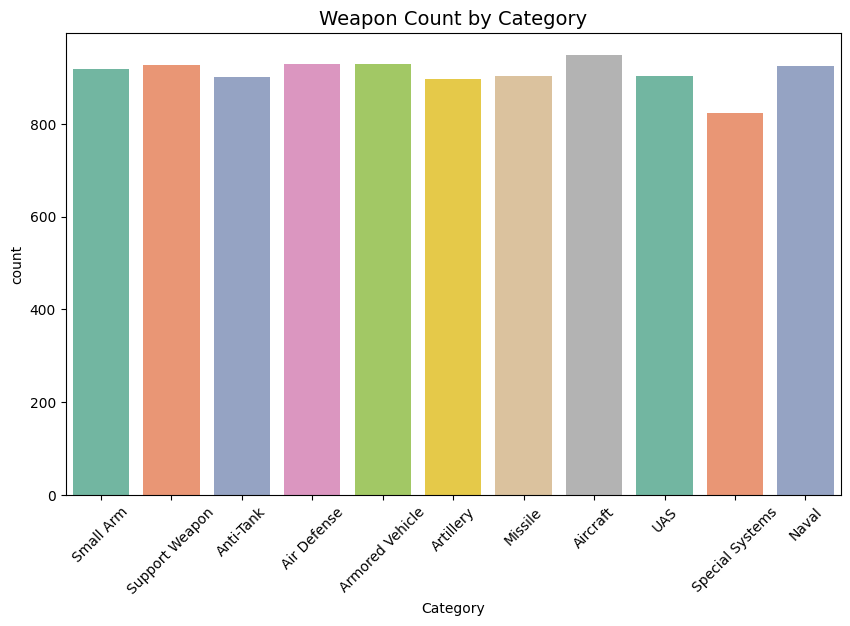

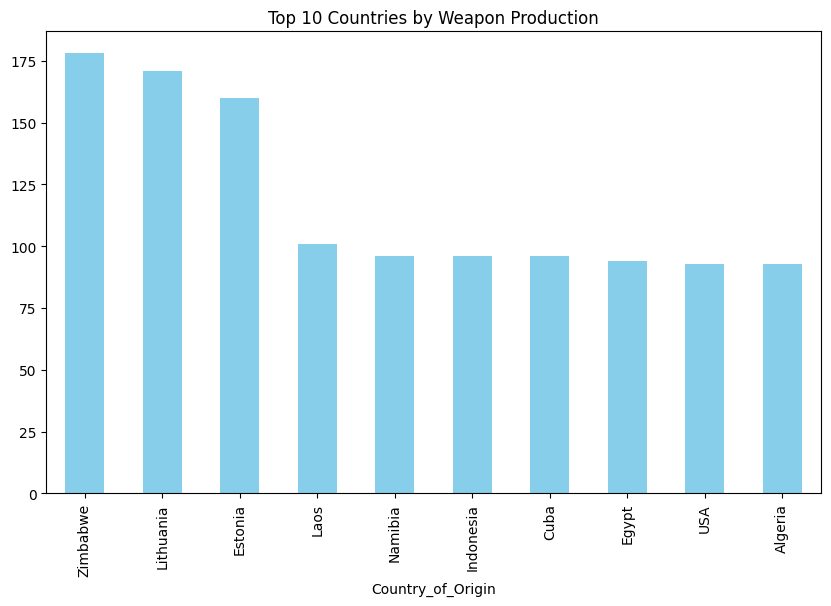

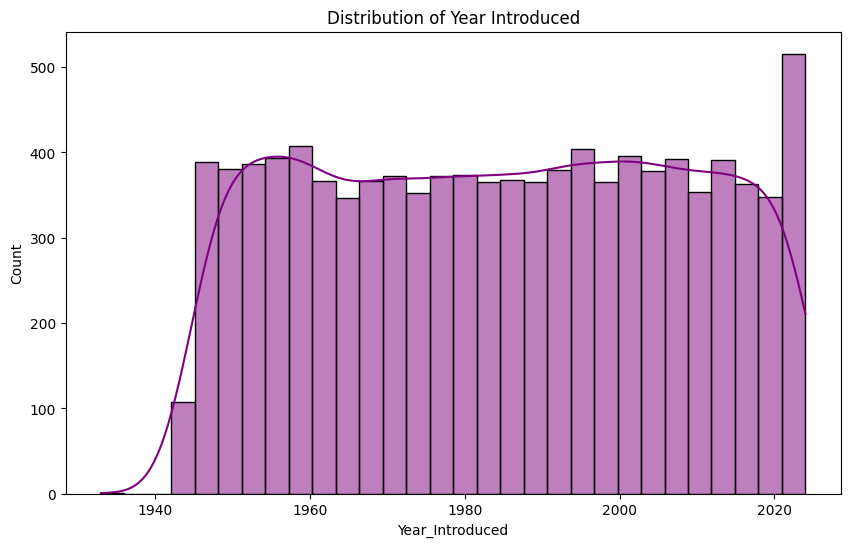

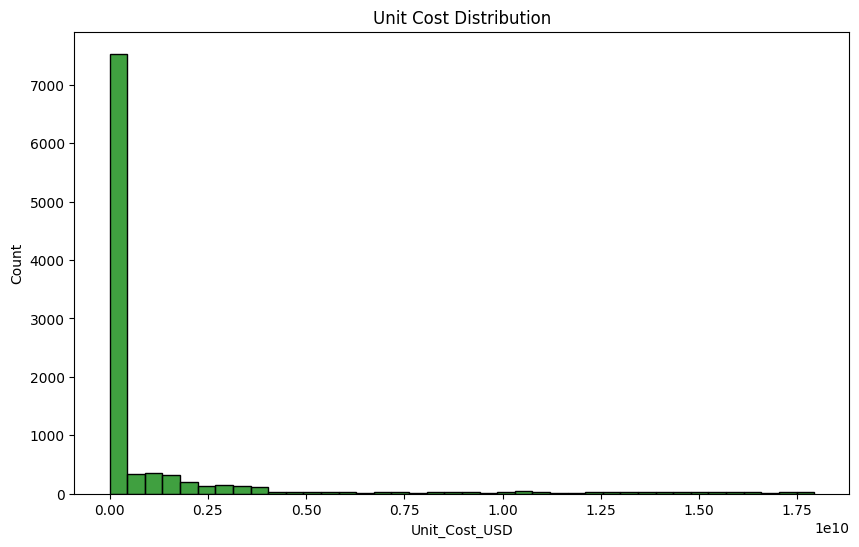

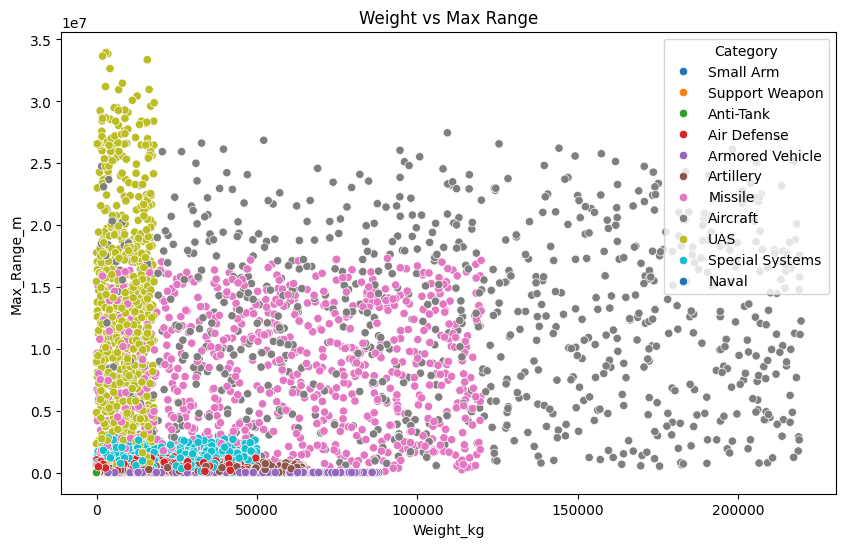

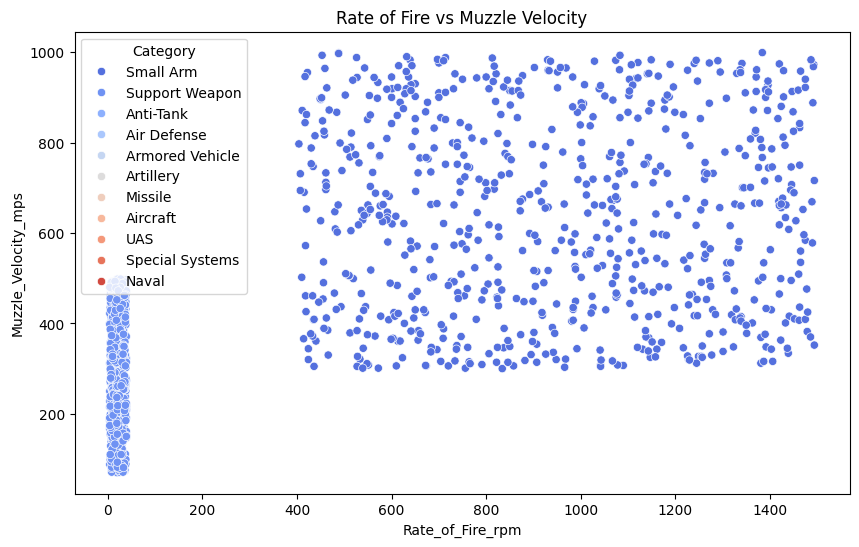

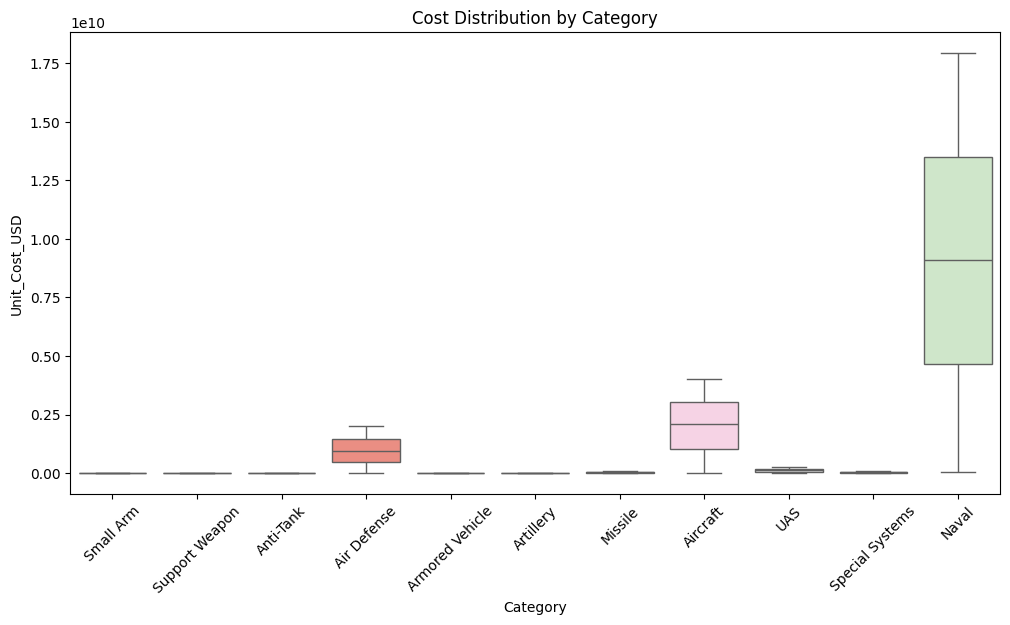

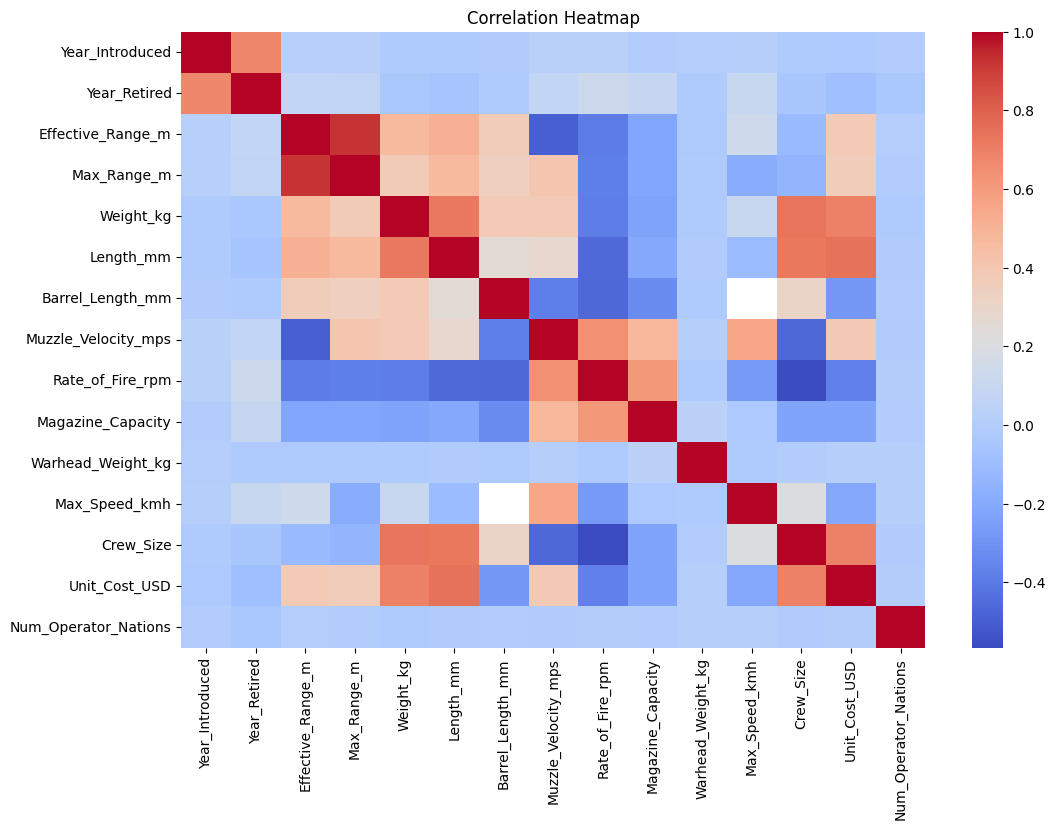

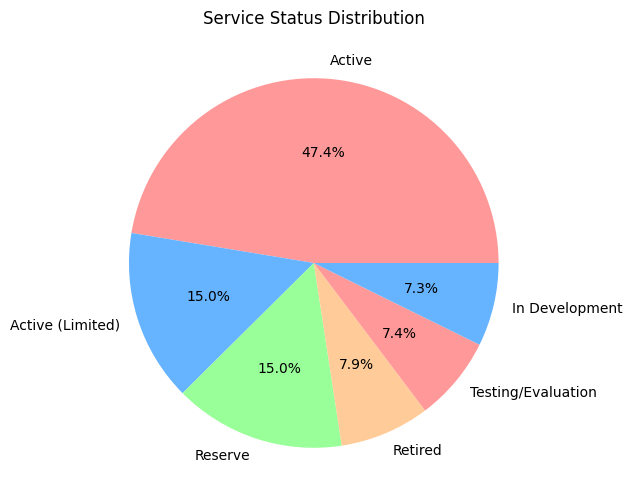

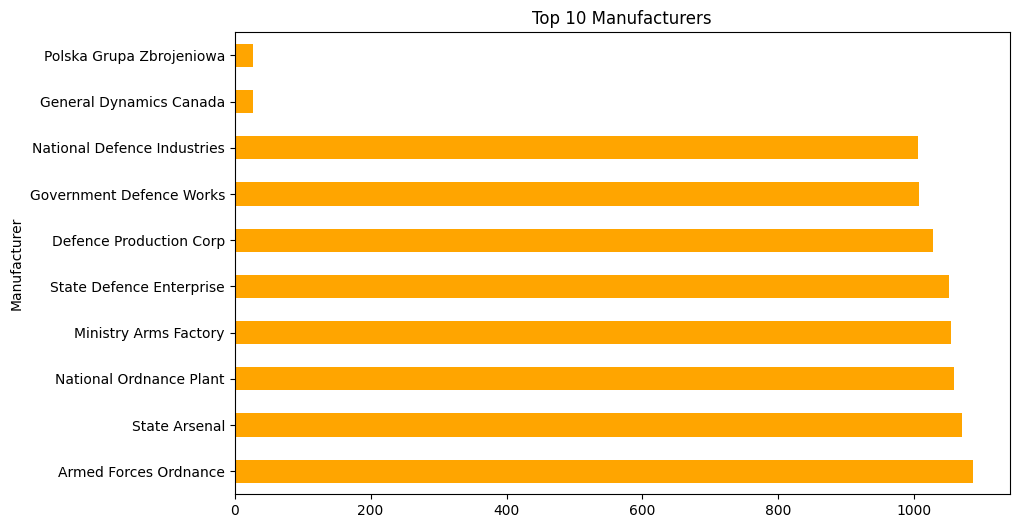

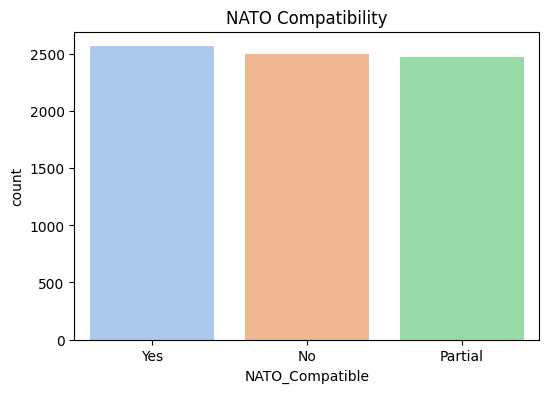

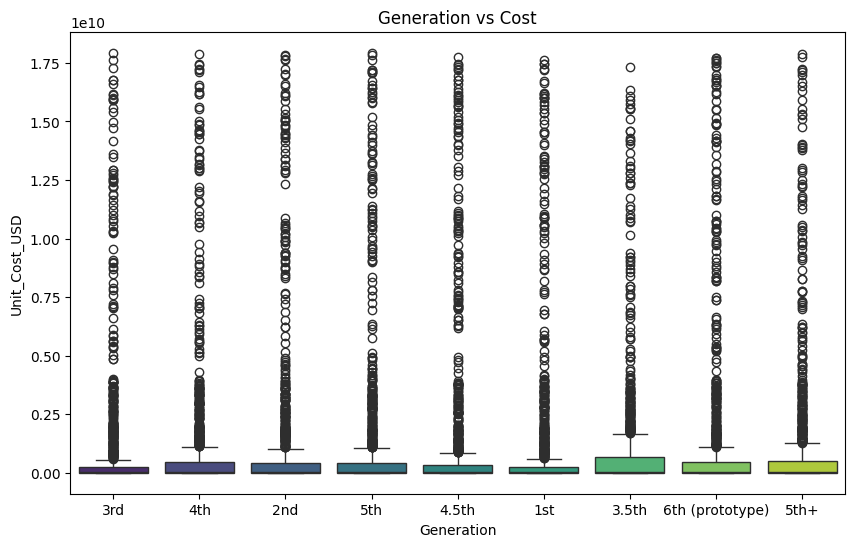

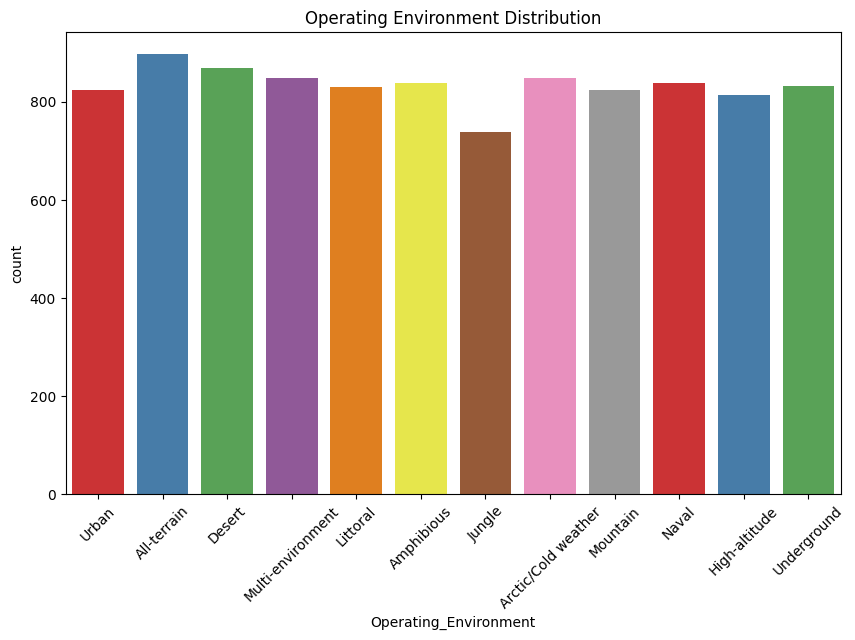

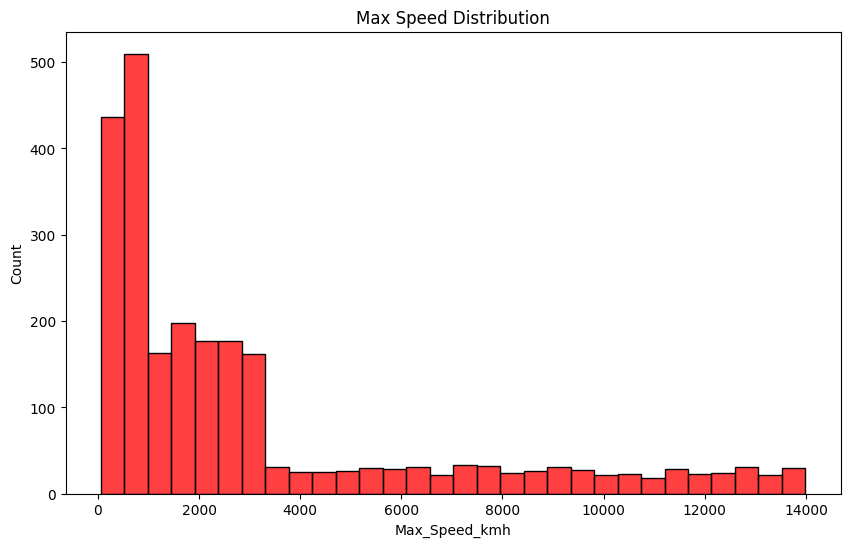

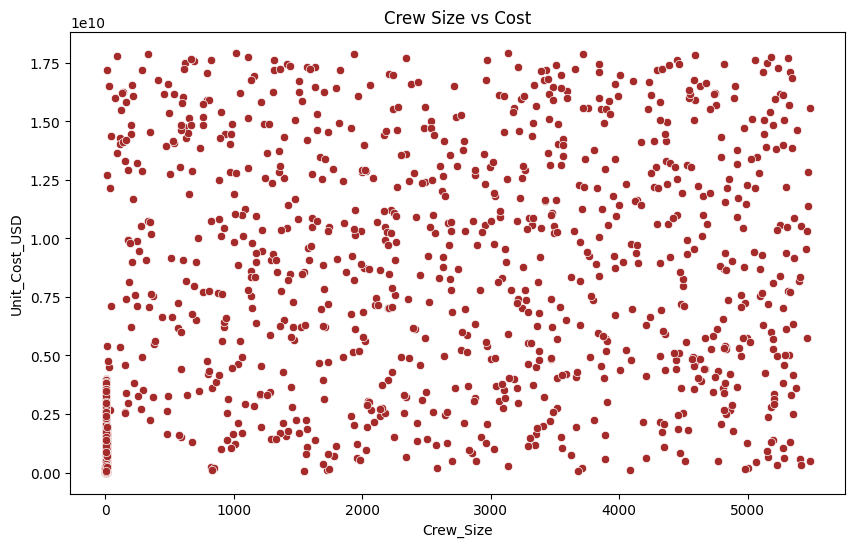

In [12]:
df = df.drop_duplicates()

# Convert numeric columns properly
num_cols = [
    'Year_Introduced', 'Year_Retired', 'Effective_Range_m', 'Max_Range_m',
    'Weight_kg', 'Length_mm', 'Barrel_Length_mm', 'Muzzle_Velocity_mps',
    'Rate_of_Fire_rpm', 'Magazine_Capacity', 'Warhead_Weight_kg',
    'Max_Speed_kmh', 'Crew_Size', 'Unit_Cost_USD', 'Num_Operator_Nations'
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# =========================================
# 1. COUNT OF WEAPONS BY CATEGORY
# =========================================
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Category', palette='Set2')
plt.title("Weapon Count by Category", fontsize=14)
plt.xticks(rotation=45)
plt.show()

# =========================================
# 2. TOP 10 COUNTRIES BY WEAPON COUNT
# =========================================
plt.figure(figsize=(10,6))
df['Country_of_Origin'].value_counts().head(10).plot(
    kind='bar', color='skyblue'
)
plt.title("Top 10 Countries by Weapon Production")
plt.show()

# =========================================
# 3. YEAR INTRODUCED DISTRIBUTION
# =========================================
plt.figure(figsize=(10,6))
sns.histplot(df['Year_Introduced'], bins=30, color='purple', kde=True)
plt.title("Distribution of Year Introduced")
plt.show()

# =========================================
# 4. COST DISTRIBUTION
# =========================================
plt.figure(figsize=(10,6))
sns.histplot(df['Unit_Cost_USD'], bins=40, color='green')
plt.title("Unit Cost Distribution")
plt.show()

# =========================================
# 5. WEIGHT VS RANGE SCATTER
# =========================================
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='Weight_kg',
    y='Max_Range_m',
    hue='Category',
    palette='tab10'
)
plt.title("Weight vs Max Range")
plt.show()

# =========================================
# 6. RATE OF FIRE VS MUZZLE VELOCITY
# =========================================
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='Rate_of_Fire_rpm',
    y='Muzzle_Velocity_mps',
    hue='Category',
    palette='coolwarm'
)
plt.title("Rate of Fire vs Muzzle Velocity")
plt.show()

# =========================================
# 7. BOXPLOT: COST BY CATEGORY
# =========================================
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='Category', y='Unit_Cost_USD', palette='Set3')
plt.xticks(rotation=45)
plt.title("Cost Distribution by Category")
plt.show()

# =========================================
# 8. HEATMAP (CORRELATION)
# =========================================
plt.figure(figsize=(12,8))
corr = df[num_cols].corr()
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

# =========================================
# 9. PIE CHART: SERVICE STATUS
# =========================================
plt.figure(figsize=(6,6))
df['Service_Status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#ff9999','#66b3ff','#99ff99','#ffcc99']
)
plt.title("Service Status Distribution")
plt.ylabel("")
plt.show()

# =========================================
# 10. TOP MANUFACTURERS
# =========================================
plt.figure(figsize=(10,6))
df['Manufacturer'].value_counts().head(10).plot(
    kind='barh',
    color='orange'
)
plt.title("Top 10 Manufacturers")
plt.show()

# =========================================
# 11. NATO COMPATIBILITY COUNT
# =========================================
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='NATO_Compatible', palette='pastel')
plt.title("NATO Compatibility")
plt.show()

# =========================================
# 12. GENERATION VS COST
# =========================================
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Generation', y='Unit_Cost_USD', palette='viridis')
plt.title("Generation vs Cost")
plt.show()

# =========================================
# 13. OPERATING ENVIRONMENT DISTRIBUTION
# =========================================
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Operating_Environment', palette='Set1')
plt.xticks(rotation=45)
plt.title("Operating Environment Distribution")
plt.show()

# =========================================
# 14. MAX SPEED DISTRIBUTION
# =========================================
plt.figure(figsize=(10,6))
sns.histplot(df['Max_Speed_kmh'], bins=30, color='red')
plt.title("Max Speed Distribution")
plt.show()

# =========================================
# 15. CREW SIZE VS COST
# =========================================
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='Crew_Size',
    y='Unit_Cost_USD',
    color='brown'
)
plt.title("Crew Size vs Cost")
plt.show()

## Feature engineering


Logistic Regression
Accuracy: 1.0000
AUC: 1.0000

Random Forest
Accuracy: 0.9990
AUC: 1.0000

Gradient Boosting
Accuracy: 1.0000
AUC: 1.0000


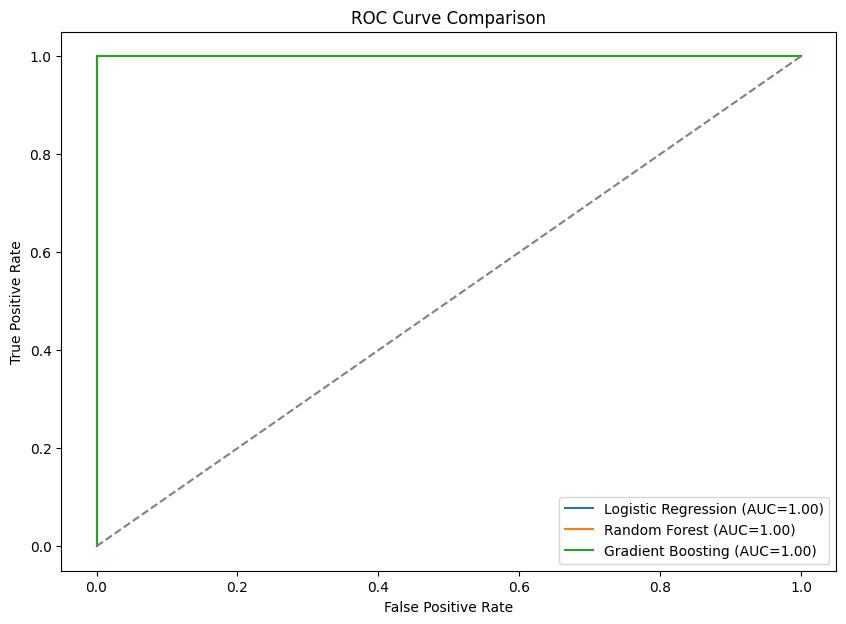

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

df['target'] = (
    (df['Max_Range_m'] > df['Max_Range_m'].median()) &
    (df['Muzzle_Velocity_mps'] > df['Muzzle_Velocity_mps'].median())
).astype(int)

# Drop rows with missing target-related values
df = df.dropna(subset=['target'])

# =========================================
# DROP LEAKY / USELESS COLUMNS
# =========================================
drop_cols = ['ID', 'Weapon_Name', 'Notes']
X = df.drop(columns=drop_cols + ['target'])
y = df['target']

# =========================================
# TRAIN TEST SPLIT (BEFORE PROCESSING)
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================================
# COLUMN TYPES
# =========================================
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# =========================================
# PREPROCESSING PIPELINE (NO LEAKAGE)
# =========================================
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

# =========================================
# MODELS
# =========================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier()
}

# =========================================
# TRAIN, EVALUATE, ROC CURVE
# =========================================
plt.figure(figsize=(10, 7))

for name, model in models.items():

    # Full pipeline (preprocessing + model)
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"AUC: {auc:.4f}")

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

# =========================================
# FINAL ROC PLOT
# =========================================
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## Thank you...pls upvote!!!!!!!!!!!